# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Nicholas Noverhino Ama Payong
- **Email:** nicholasnoverhino@gmail.com
- **ID Dicoding:** ichoo13

## Menentukan Pertanyaan Bisnis

- Bagaimana perbandingan pola penyewaan antara pengguna biasa (*casual*) dan anggota (*registered*) pada hari kerja (*workingday*) dibandingkan akhir pekan/hari libur (*holiday*) selama tahun 2011-2012, untuk menentukan di hari apa perusahaan harus memfokuskan promosi keanggotaan (membership)?
- Bagaimana pengaruh kelembapan (*hum*) dan temperatur suhu (*temp*) terhadap jumlah penyewaan (*cnt*) di hari kerja (*workingday*) selama periode 2011-2012, agar perusahaan dapat mengantisipasi lonjakan permintaan dengan menyiapkan stok maksimal?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Load the latest version
df_day = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/bike-sharing-dataset",
  "day.csv",
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_hour = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/bike-sharing-dataset",
  "hour.csv",
)

Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.
Using Colab cache for faster access to the 'bike-sharing-dataset' dataset.


In [ ]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset pada kaggle sudah berhasil digunakan yang dibuktikan dengan dapat digunakannya fungsi `df.head()`

### Assessing Data

In [ ]:
#Melihat informasi pada dataset day.csv
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
#Melihat informasi pada dataset hour.csv
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


**Insight:**
- Setelah di cek menggunakan `df.info` untuk dataset day dan hour, terdapat kolom hr(hour) yang hanya dimiliki oleh dataset hour.csv, sedangkan dataset day.csv tidak memiliki kolom tersebut.
- Kolom `dteday` masih memiliki tipe data object, harus kita ubah ke dalam bentuk datetime
- Tidak terdapat data yang kosong atau null untuk setiap df.

In [ ]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


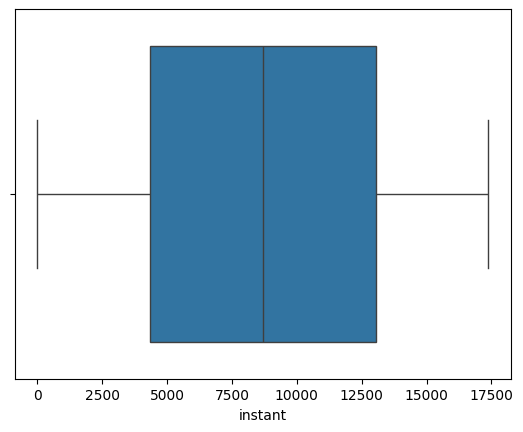

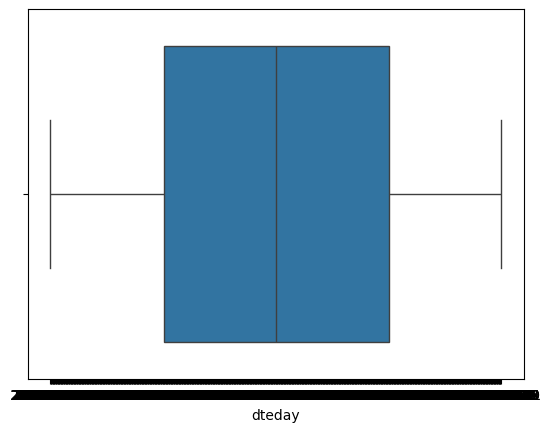

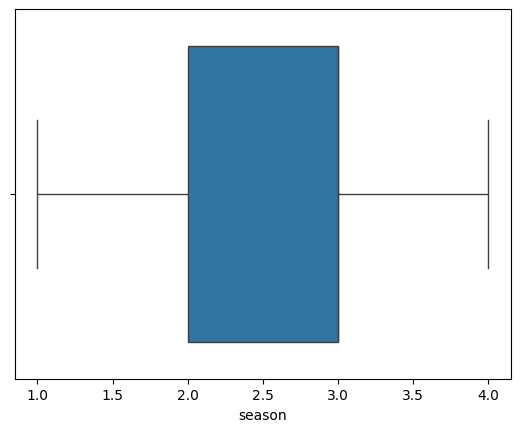

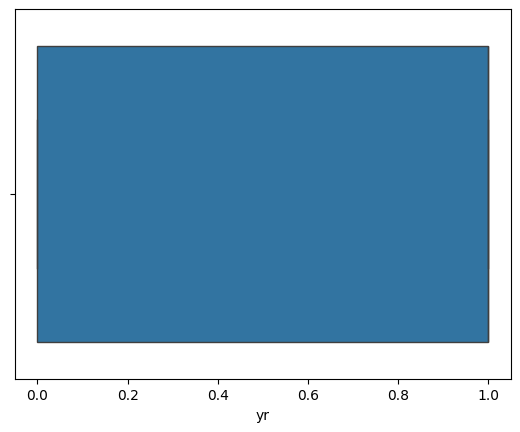

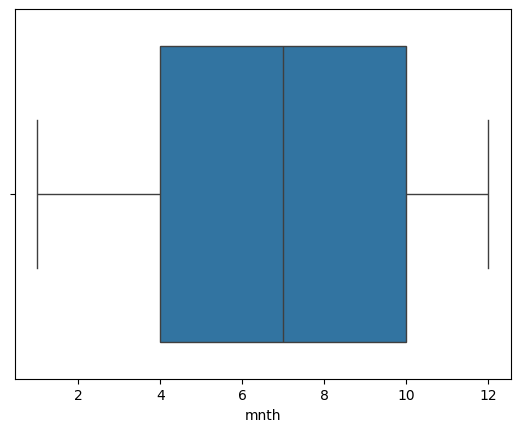

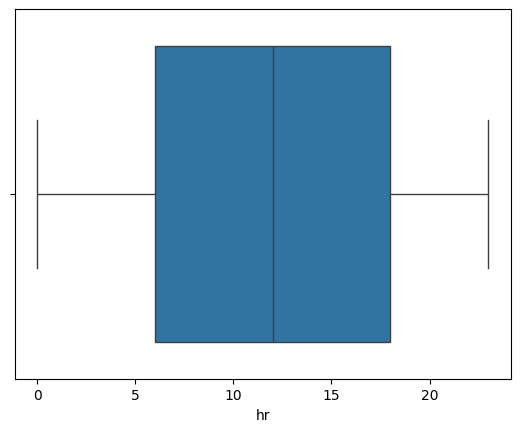

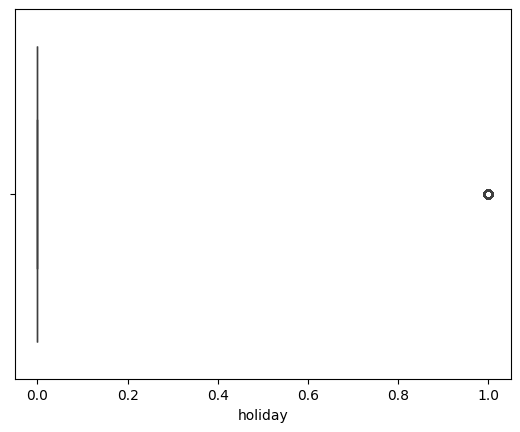

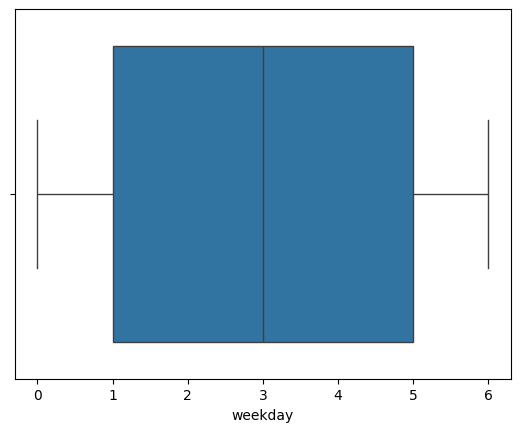

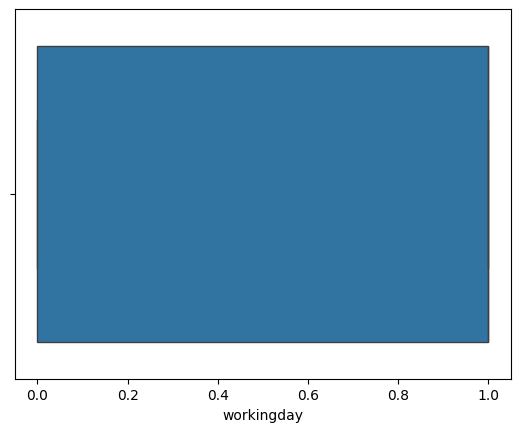

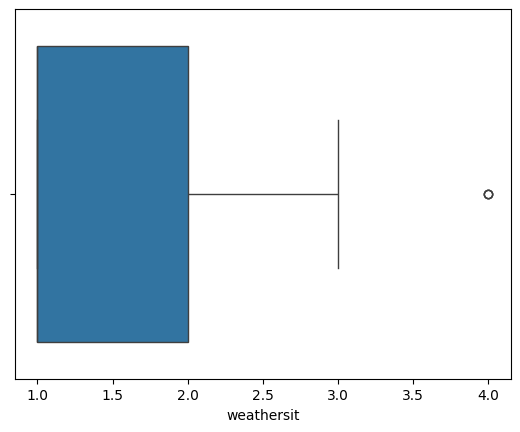

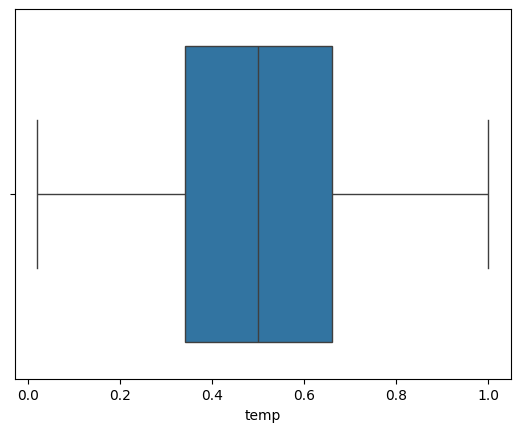

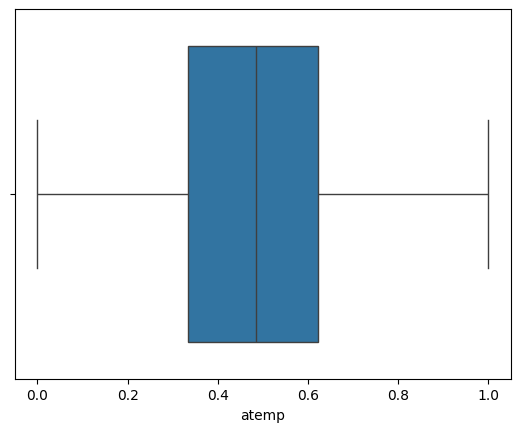

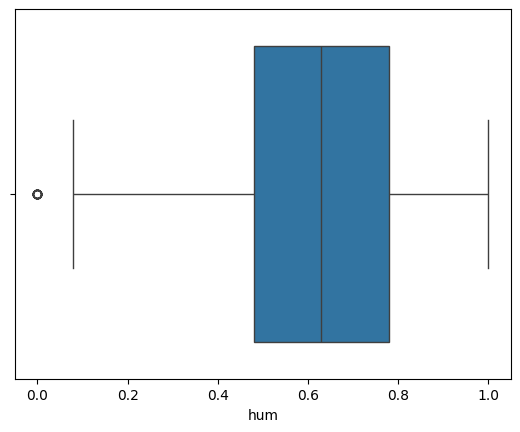

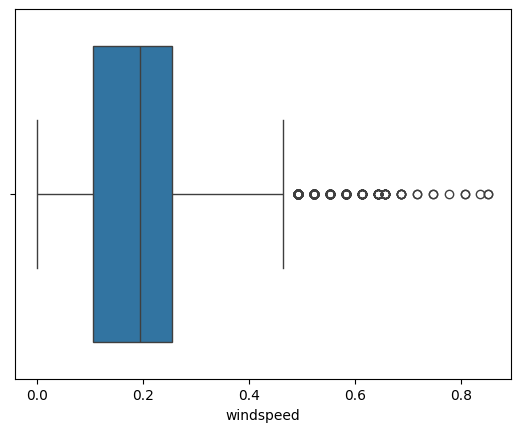

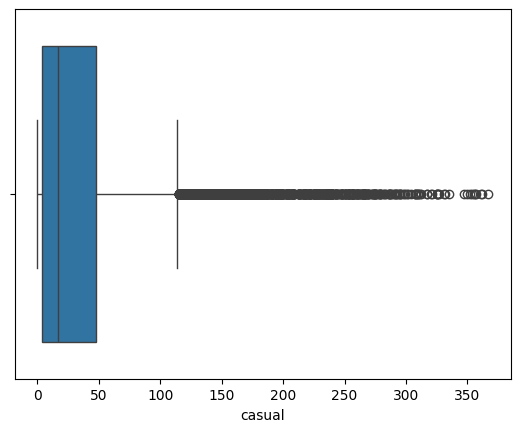

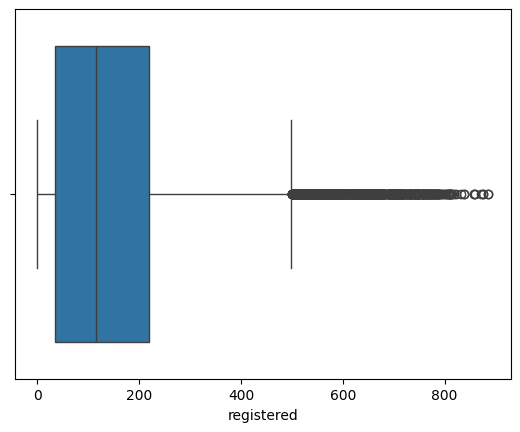

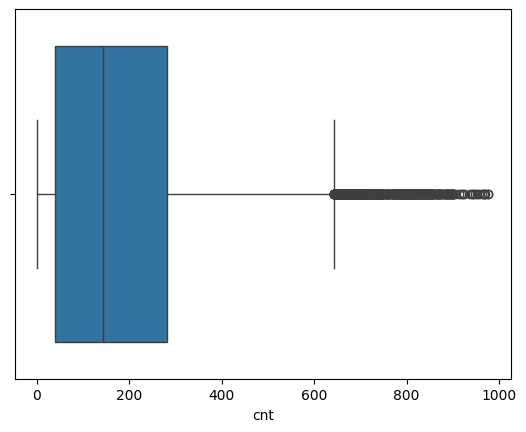

In [ ]:
for col in df_hour.columns:
    sns.boxplot(data = df_hour, x=col)
    plt.show()

In [ ]:
# Fokus kita hanya menggunakan data hour saja
# Cek data duplikat
df_hour.duplicated().sum()

np.int64(0)

**Insight:**
- Ringkasan statistik juga terlihat baik baik saja
- Pada kolom `casual`, `windspeed`, `registered`, dan `cnt` memiliki *outlier* yang cukup banyak. Namun, saya memilih untuk tidak menghapusnya karena potensi *outlier* ini merepresentasikan kondisi nyata, seperti lonjakan sewa yang ekstrem, pengaruh kondisi cuaca pada `windspeed`, dan peningkatan jumlah pengguna `casual` dan `registered` yang bervariasi tergantung pada hari tertentu. Menghapus atau mengganti *outlier* ini dapat menghilangkan informasi penting yang relevan untuk analisis.
- Setelah di cek juga tidak terdapat adanya data yang duplikat.

### Cleaning Data

In [ ]:
df_hour["dteday"] = df_hour["dteday"].astype("datetime64[ns]")
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Kolom `dteday` sudah berubah tipe datanya menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...

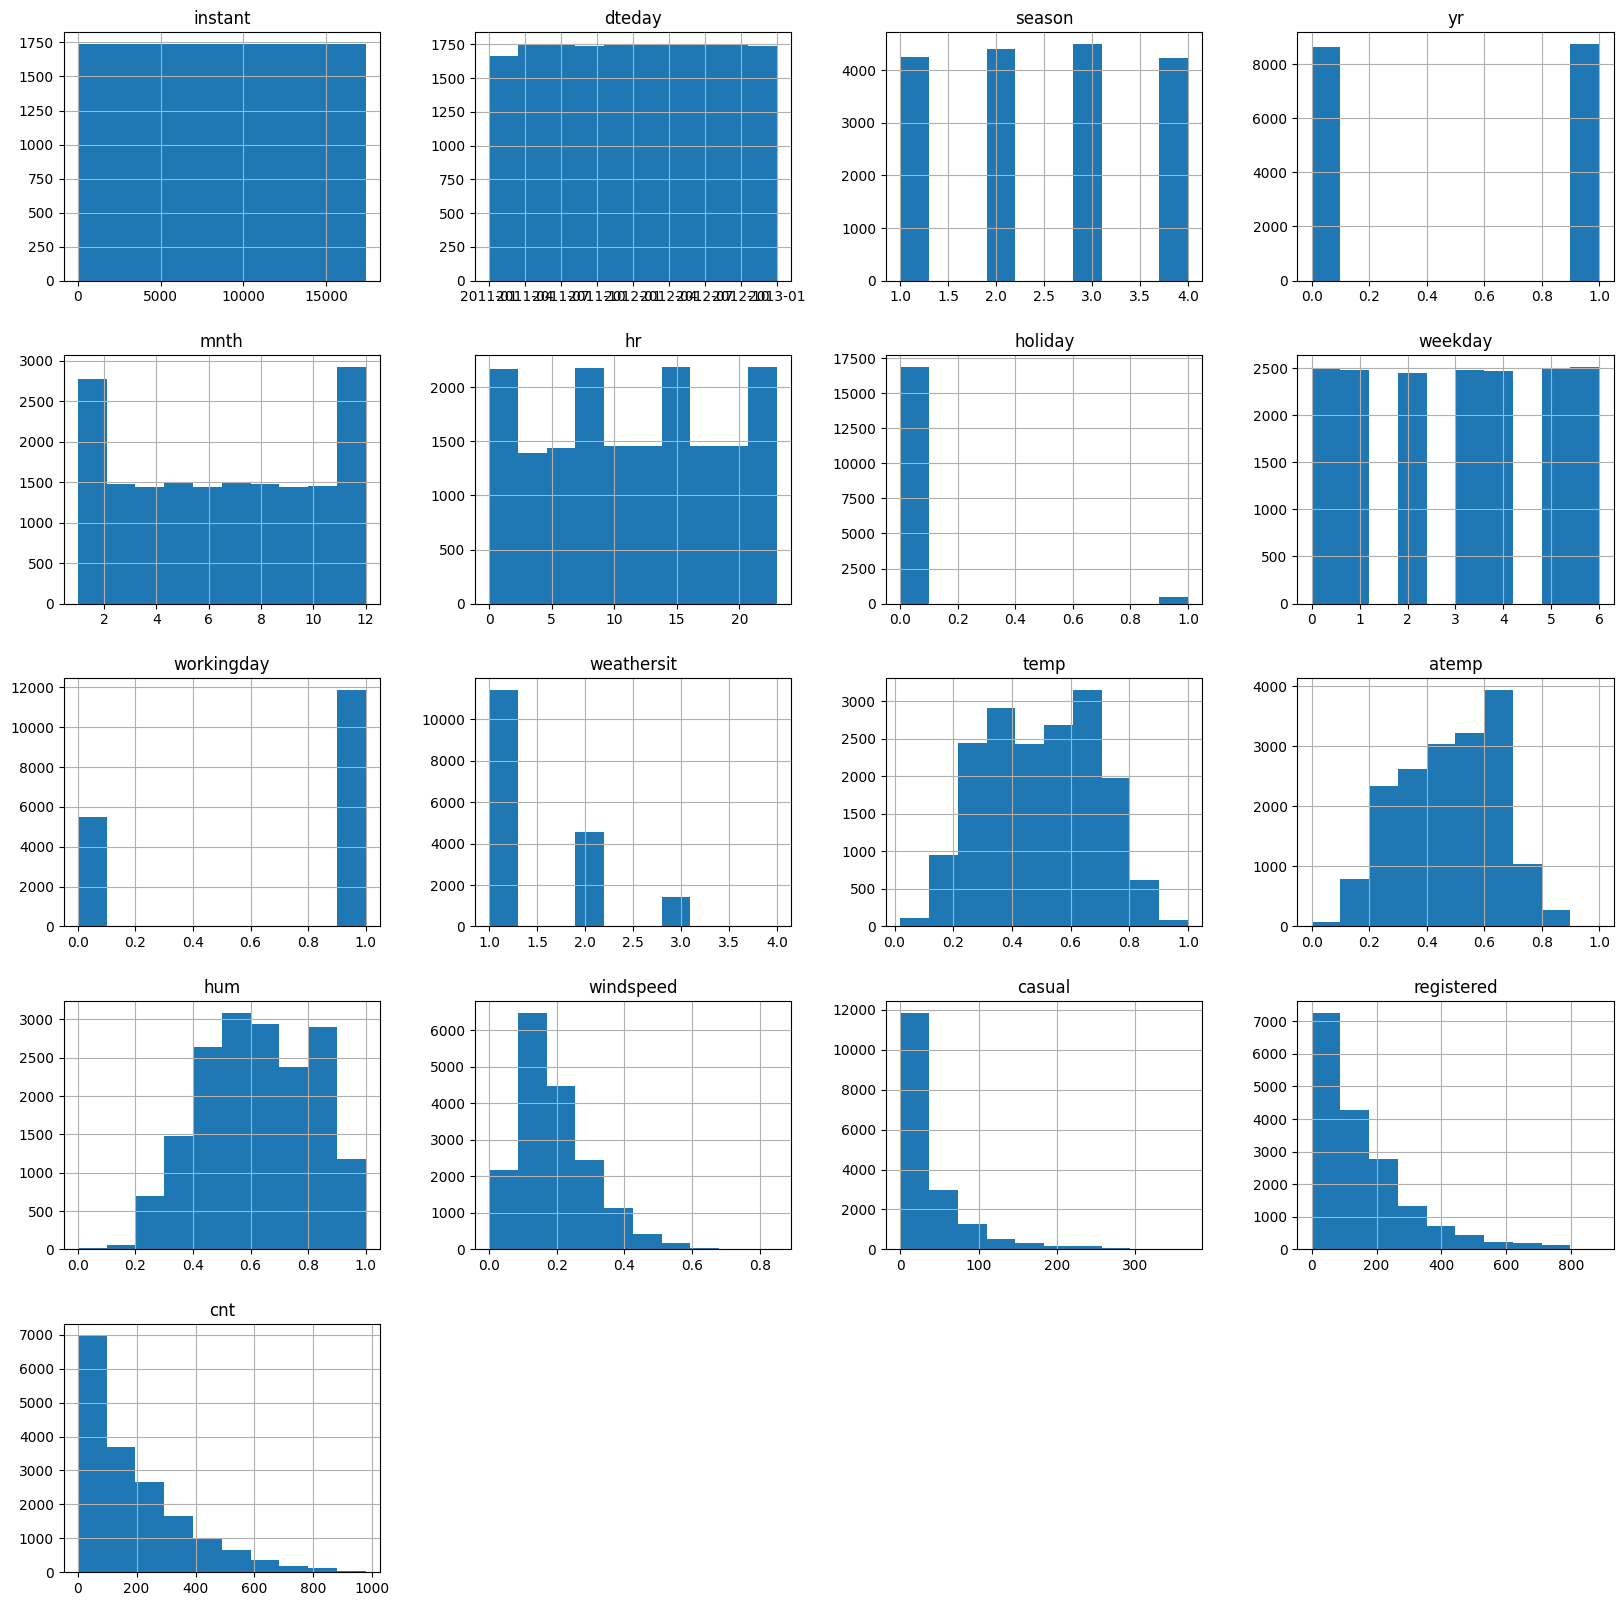

In [ ]:
df_hour.hist(figsize=(20,20))
plt.show()

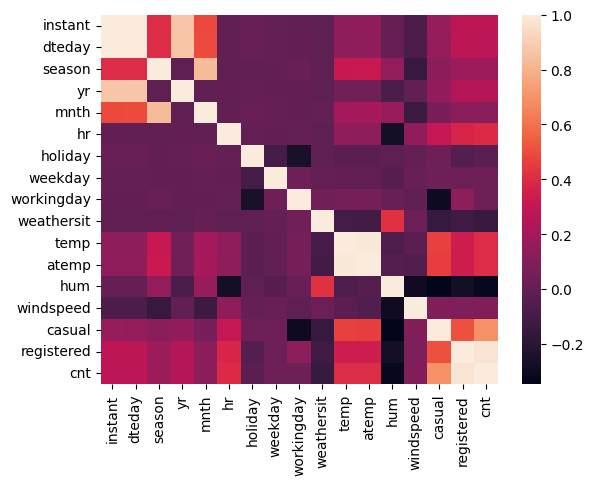

In [ ]:
sns.heatmap(df_hour.corr())
plt.show()

**Insight:**
- Pertama, saya membuat histogram untuk masing-masing kolom yang terdapat dalam dataframe yang saya gunakan df_hour menggunakan fungsi `df_hour.hist()`. Hal yang aku dapat dari visualisasi histogram masing masing kolom adalah, mayoritas variabel sudah berdistribusi normal, adapula yang memiliki kemiringan (skewness) ke kanan seperti (*windspeed, casual, registered, cnt*).
- Kedua, saya membuat visualisasi korelasi setiap kolom yang ada menggunakan `sns.heatmap(df_hour.corr())`. Dapat terlihat juga pada hasil visualisasi yang berupa heatmap dan legenda nya merupakan hasil korelasinya. Sebagaimana fokusku berada pada *cnt*, aku bisa melihat korelasi *cnt* terhadap semua kolom lainnya. Mayoritas kolom memiliki korelasi yang positif dengan *cnt*, kecuali *hum* (kelembapan) dan *weathersit* (cuaca) yang memiliki korelasi negatif

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [ ]:
df_question_1 = df_hour[['casual', 'registered', 'workingday', 'holiday']].copy()
df_question_1.head()

,casual,registered,workingday,holiday
0,3,13,0,0
1,8,32,0,0
2,5,27,0,0
3,3,10,0,0
4,0,1,0,0


In [ ]:
# Memisahkan label untuk working day, holiday, dan non-workingday
def jenis_hari(workingday, holiday):
    if workingday == 1 and holiday == 0:
      return 'Working Day'
    elif workingday == 0 and holiday == 1:
      return 'Holiday'
    else:
      return 'Non-Working Day'

In [ ]:
#Masukkan kolom jenis hari pada dataframe
df_question_1['jenis_hari'] = df_question_1.apply(lambda x: jenis_hari(x['workingday'], x['holiday']), axis=1)
df_question_1.head()

,casual,registered,workingday,holiday,jenis_hari
0,3,13,0,0,Non-Working Day
1,8,32,0,0,Non-Working Day
2,5,27,0,0,Non-Working Day
3,3,10,0,0,Non-Working Day
4,0,1,0,0,Non-Working Day


In [ ]:
df_question_1_grouped = df_question_1.groupby(by='jenis_hari')[['casual', 'registered']].sum()
df_question_1_grouped

,casual,registered
jenis_hari,,
Holiday,22359,56076
Non-Working Day,294373,627461
Working Day,303285,1989125


**Insight:**
- Pada tahap ini, saya memisahkan terlebih dahulu dari dataset utama dengan mengcopy kolom *casual, registered, workingday,* dan *holiday* untuk keperluan analisis pertanyaan pertama saya.
- Setelah dipisahkan, saya mulai membuat fungsi `jenis_hari` untuk mengetahui mana yang termasuk hari kerja (*workingday*), hari libur(*holiday*), atau hari weekend(*non-working day*)
- Selanjutnya, saya memasukkan kolom baru bernama `jenis_hari` yang akan berisi 3 nilai yang sudah aku deklarasikan pada fungsi sebelumnya.
- Terakhir, saya membuat pivot table yang dibuat berdasarkan jenis_hari, kemudian membandingkannya dengan *casual* dan *registered* yang telah di dijumlahkan totalnya.

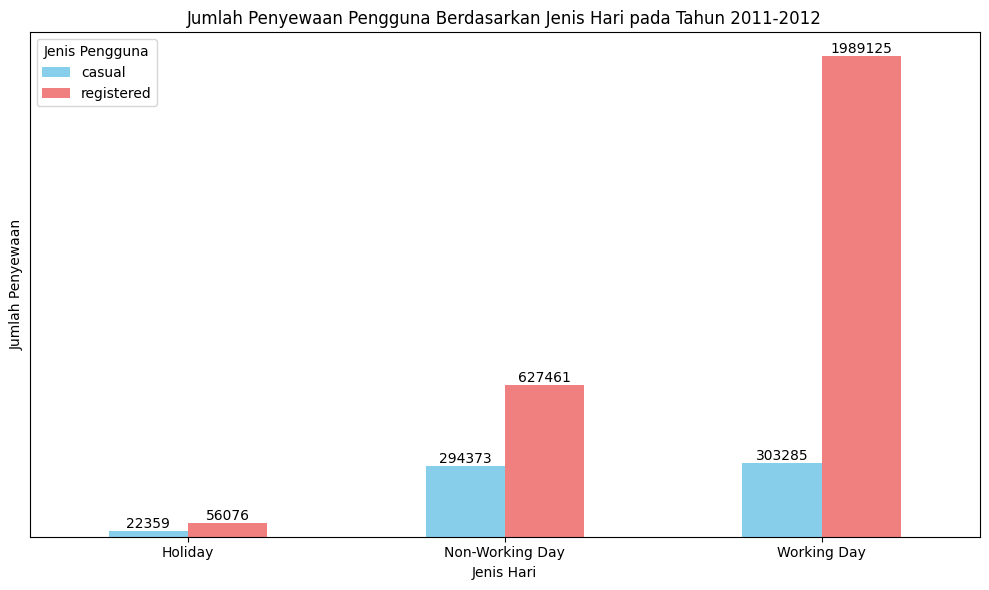

In [ ]:
df_question_1_grouped.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightcoral'])

# Add numbers on top of each bar
for container in plt.gca().containers:
  plt.bar_label(container, fmt='%d', label_type='edge')

plt.title('Jumlah Penyewaan Pengguna Berdasarkan Jenis Hari pada Tahun 2011-2012')
plt.xlabel('Jenis Hari')
plt.ylabel('Jumlah Penyewaan')
plt.yticks([])
plt.xticks(rotation=0)
plt.legend(title='Jenis Pengguna')
plt.ticklabel_format(style='plain', axis='y') # Mematikan format "1e6"
plt.tight_layout()
plt.show()

**Insight:**
- Dapat terlihat pada grafik batang (*barplot*) ini, setelah dikelompokkan berdasarkan jenis hari yaitu (*holiday, non-working day, dan working day*), jumlah penyewaan terbesar adalah pada saat hari kerja (*workingday*). Dengan begitu, pihak rental sepeda dapat memfokuskan jumlah penyewaaannya di hari kerja.
- Penyewaan terbanyak dicapai oleh member (*registered*) dengan capaian sebanyak **1,9 juta penyewaaan** pada hari kerja. Ini juga menjadi fokus pihak rental agar memperbanyak benefit untuk para member yang telah mendaftar
- Para pengguna kasual cenderung beraktivitas lebih banyak pada akhir pekan dan hari libur yang dimana menembus angka 294 ribu penyewaan untuk akhir pekan dan 22 ribu untuk hari kerja. Alasannya adalah karena akhir pekan yang harinya hanya ada 2 saja yaitu sabtu dan minggu, sedangkan hari libur bergantung pada hari libur nasional yang terjadi selama tahun 2011-2012.
- Menurut saya, hasil ini juga memberikan pertimbangan lain, yang dimana hari kerja biasanya sebanyak 5 hari, hari libur tergantung dengan hari libur nasional atau hari libur kenegaraan, sedangan hari selain hari libur dan hari kerja (weekend) hanya terjadi 2 hari saja yaitu sabtu dan minggu. Jadi memang total penyewaan terbanyak ada pada hari kerja karena jumlah harinya yang banyak.

### Pertanyaan 2:

In [ ]:
#Memisahkan cnt yang ada pada hari kerja
df_question_2 = df_hour[df_hour['workingday'] == 1]
df_question_2.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
47,48,2011-01-03,1,0,1,0,0,1,1,1,0.22,0.1970,0.44,0.3582,0,5,5
48,49,2011-01-03,1,0,1,1,0,1,1,1,0.20,0.1667,0.44,0.4179,0,2,2
49,50,2011-01-03,1,0,1,4,0,1,1,1,0.16,0.1364,0.47,0.3881,0,1,1
50,51,2011-01-03,1,0,1,5,0,1,1,1,0.16,0.1364,0.47,0.2836,0,3,3
51,52,2011-01-03,1,0,1,6,0,1,1,1,0.14,0.1061,0.50,0.3881,0,30,30


**Insight:**
- Kita membuat dataframe baru dengan kondisi dimana hari tersebut merupakan workingday atau hari kerja

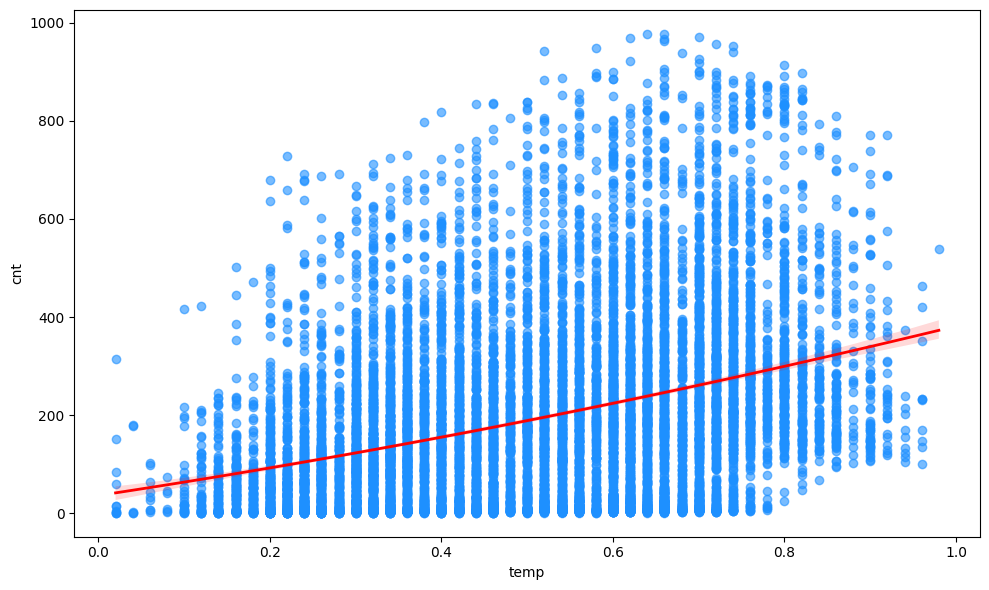

In [ ]:
plt.figure(figsize=(10, 6))

# Kita pakai sns.regplot() bukan sns.scatterplot() biasa.
# Kenapa? Karena regplot otomatis menggambarkan GARIS TREN lurus
# di tengah titik-titik untuk membantu kita melihat korelasinya (naik/turun).
sns.regplot(
    data=df_question_2,
    x='temp',       # Sumbu X adalah Suhu
    y='cnt',        # Sumbu Y adalah Jumlah Sewa
    scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'}, # Titik biru transparan
    line_kws={'color': 'red', 'linewidth': 2},          # Garis tren warna merah
    order=2
)

plt.tight_layout()
plt.show()

**Insight:**
- Pada grafik diatas, hubungan antara suhu dan jumlah penyewaan sendiri memiliki korelasi yang positif, yang dimana semakin tinggi suhu udaranya, jumlah penyewaan cenderung semakin naik, begitupun sebaliknya.

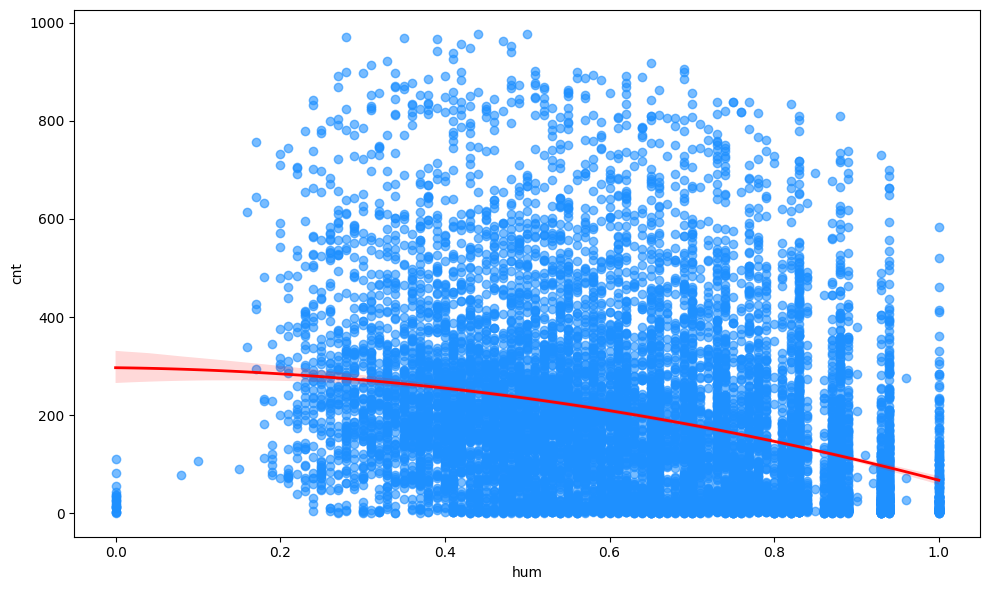

In [ ]:
plt.figure(figsize=(10, 6))

# Kita pakai sns.regplot() bukan sns.scatterplot() biasa.
# Kenapa? Karena regplot otomatis menggambarkan GARIS TREN lurus
# di tengah titik-titik untuk membantu kita melihat korelasinya (naik/turun).
sns.regplot(
    data=df_question_2,
    x='hum',       # Sumbu X adalah Kelembapan
    y='cnt',        # Sumbu Y adalah Jumlah Sewa
    scatter_kws={'alpha': 0.6, 'color': 'dodgerblue'}, # Titik biru transparan
    line_kws={'color': 'red', 'linewidth': 2},          # Garis tren warna merah
    order=2
)

plt.tight_layout()
plt.show()

**Insight:**
- Pada grafik diatas, hubungan antara kelembapan dan jumlah penyewaan sendiri memiliki korelasi yang negatif, yang dimana semakin tinggi kelembapan udaranya, jumlah penyewaan cenderung lebih sedikit, begitupun sebaliknya.

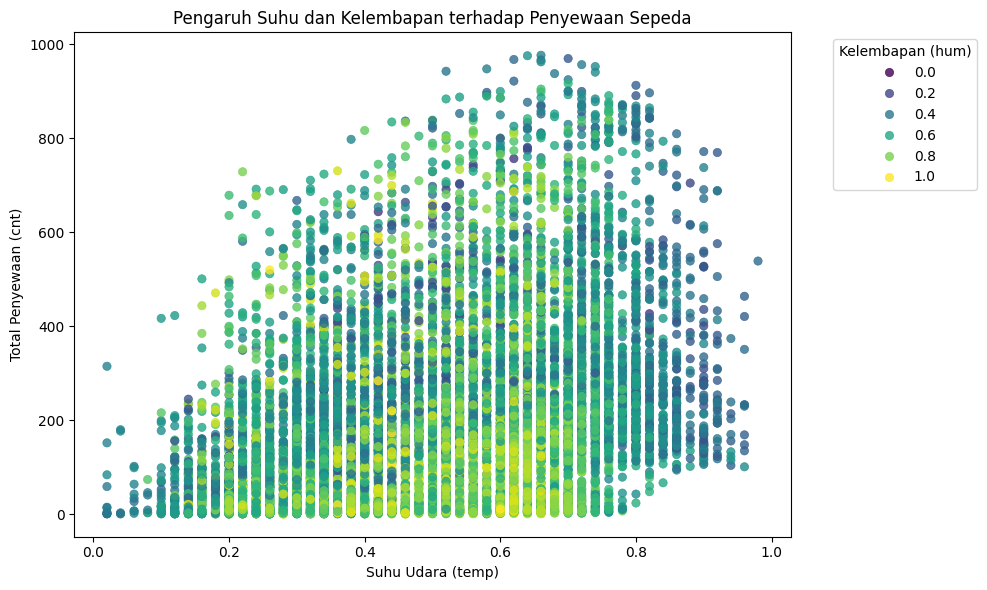

In [ ]:
plt.figure(figsize=(10, 6))

# Membuat scatter plot dengan 3 variabel
scatter = sns.scatterplot(
    data=df_question_2,
    x='temp',       # Sumbu X (Suhu)
    y='cnt',        # Sumbu Y (Jumlah Sewa)
    hue='hum',      # WARNA (Kelembapan)
    palette='viridis', # Pilihan gradasi warna (kuning ke ungu gelap)
    alpha=0.8,      # Transparansi agar titik yang menumpuk tetap terlihat
    edgecolor=None  # Menghilangkan garis pinggir titik biar lebih mulus
)

# Mempercantik tampilan
plt.title('Pengaruh Suhu dan Kelembapan terhadap Penyewaan Sepeda')
plt.xlabel('Suhu Udara (temp)')
plt.ylabel('Total Penyewaan (cnt)')

# Menggeser legenda/keterangan warna ke luar kotak grafik biar nggak nutupin data
plt.legend(title='Kelembapan (hum)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
- Pada grafik scatterplot yang menerapkan 3 variabel utama, yaitu kelembapan (hum), suhu (temp), dan jumlah penyewaan (cnt). Dapat terlihat, penyewaan diatas 800 itu terjadi ketika suhu udara berada di sekitar 0,5-0,8 dalam skala normalisasi suhu. Ini berarti para penyewa lebih memilih suhu yang hangat dan tidak terlalu panas untuk menyewa sepeda.
- Dapat terlihat juga pada rentang 0,5-0,8 untuk suhu dan jjumlah penyewaan diatas 800, mayoritas kelembapan berada pada rentang 0,0-0,4 dengan titik berwarna biru hingga ungu. Artinya para penyewa lebih banyak menyewa ketika suhu sedang hangat dan kelembapan yang rendah.
- Jumlah penyewaan juga cenderung rendah ketika kelembapan udara yang tinggi ditandai dengan titik yang mulai berwarna kuning. Suhu udara yang rendah dan tinggi juga mempengaruhi jumlah penyewaan yang berada di bawah 800.

## Analisis Lanjutan (Opsional)

In [4]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set page config
st.set_page_config(layout='wide', page_title='Analisis Data Bike Sharing')

st.title('Proyek Analisis Data: Bike Sharing Dataset')
st.markdown('### Oleh: Nicholas Noverhino Ama Payong')

# --- Data Loading ---
st.header('1. Gathering Data')

@st.cache_data
def load_data():
    try:
        # Membaca file lokal hour.csv
        df_hour = pd.read_csv("hour.csv")
        df_hour["dteday"] = pd.to_datetime(df_hour["dteday"])
        return df_hour
    except FileNotFoundError:
        st.error("File 'hour.csv' tidak ditemukan. Pastikan file berada di folder yang sama dengan dashboard.py!")
        st.stop()

df_hour = load_data()
st.write("Data `df_hour` berhasil dimuat. Berikut 5 baris pertama:")
st.dataframe(df_hour.head())

# --- MEMBUAT SIDEBAR INTERAKTIF ---
st.sidebar.title("🚴‍♂️ Filter Data Rental")

min_date = df_hour["dteday"].min()
max_date = df_hour["dteday"].max()

try:
    start_date, end_date = st.sidebar.date_input(
        label='Pilih Rentang Waktu',
        min_value=min_date,
        max_value=max_date,
        value=[min_date, max_date]
    )
except ValueError:
    st.error("Pastikan Anda memilih tanggal awal dan tanggal akhir.")
    st.stop()

# --- FILTERING DATA UTAMA ---
# Sekarang kita gunakan main_df sebagai sumber data untuk SEMUA grafik di bawah
main_df = df_hour[(df_hour["dteday"] >= str(start_date)) &
                  (df_hour["dteday"] <= str(end_date))]

st.write(f"Menampilkan data dari **{start_date}** hingga **{end_date}**")

# --- Visualisasi & Analisis Eksplanatori ---
st.header('2. Visualisasi & Analisis Eksplanatori')

# --- Pertanyaan 1: SMART Version ---
st.subheader('2.1. Pertanyaan Bisnis 1')
st.info("**Pertanyaan:** Bagaimana perbandingan pola penyewaan antara pengguna casual dan registered pada hari kerja dibandingkan hari libur selama tahun 2011-2012, untuk menentukan di hari apa perusahaan harus memfokuskan promosi keanggotaan (membership)?")

# Gunakan main_df agar grafik interaktif sesuai filter tanggal
df_question_1 = main_df[['casual', 'registered', 'workingday', 'holiday']].copy()

def jenis_hari(workingday, holiday):
    if workingday == 1 and holiday == 0:
        return 'Working Day'
    elif workingday == 0 and holiday == 1:
        return 'Holiday'
    else:
        return 'Non-Working Day'

df_question_1['jenis_hari'] = df_question_1.apply(lambda x: jenis_hari(x['workingday'], x['holiday']), axis=1)
df_question_1_grouped = df_question_1.groupby(by='jenis_hari')[['casual', 'registered']].sum()

fig1, ax1 = plt.subplots(figsize=(10, 6))
df_question_1_grouped.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])

for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', label_type='edge')

ax1.set_title('Jumlah Penyewaan Pengguna Berdasarkan Jenis Hari')
ax1.set_xlabel('Jenis Hari')
ax1.set_ylabel('Jumlah Penyewaan')
ax1.set_yticks([])
ax1.ticklabel_format(style='plain', axis='y')
ax1.legend(title='Jenis Pengguna')
plt.xticks(rotation=0)
plt.tight_layout()
st.pyplot(fig1)

st.markdown("""
**Insight Pertanyaan 1:**
- Berdasarkan data yang dipilih, jumlah penyewaan terbesar terjadi pada hari kerja (`Working Day`), yang sangat didominasi oleh pengguna `registered`.
- Pengguna `casual` memiliki proporsi yang cukup signifikan di hari non-kerja (akhir pekan/libur).
- **Action Plan:** Hal ini menunjukkan bahwa akhir pekan adalah momen terbaik bagi tim pemasaran untuk menawarkan promosi keanggotaan kepada pengguna `casual`.
""")

# --- Pertanyaan 2: SMART Version ---
st.subheader('2.2. Pertanyaan Bisnis 2')
st.info("**Pertanyaan:** Bagaimana pengaruh kelembapan (hum) dan temperatur suhu (temp) terhadap jumlah penyewaan (cnt) di hari kerja selama periode 2011-2012, agar perusahaan dapat mengantisipasi lonjakan permintaan dengan menyiapkan stok maksimal?")

# Gunakan main_df agar grafik interaktif sesuai filter tanggal
df_question_2 = main_df[main_df['workingday'] == 1].copy()

# Plot: Suhu, Kelembapan, dan Jumlah Sewa (3 Variabel)
fig4, ax4 = plt.subplots(figsize=(10, 6))
scatter = sns.scatterplot(
    data=df_question_2,
    x='temp',
    y='cnt',
    hue='hum',
    palette='viridis',
    alpha=0.8,
    edgecolor=None,
    ax=ax4
)
ax4.set_title('Pengaruh Suhu dan Kelembapan terhadap Penyewaan Sepeda (Hari Kerja)')
ax4.set_xlabel('Suhu Udara (temp) (Normalized)')
ax4.set_ylabel('Total Penyewaan (cnt)')
ax4.legend(title='Kelembapan (hum)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
st.pyplot(fig4)

st.markdown("""
**Insight Pertanyaan 2:**
- Terlihat pola bahwa penyewaan mencapai puncak tertinggi saat suhu hangat (0.5 - 0.8) dan tingkat kelembapan udara yang rendah (titik berwarna biru/ungu).
- **Action Plan:** Manajer operasional harus memastikan seluruh stok sepeda tersedia 100% di stasiun saat kondisi cuaca ideal ini terdeteksi di prakiraan cuaca.
""")

st.header('3. Kesimpulan Akhir (Actionable)')
st.success("""
1. **Strategi Membership (Q1):** Perusahaan disarankan memfokuskan strategi promosi keanggotaan pada akhir pekan atau hari libur. Memberikan diskon pendaftaran *member* khusus di hari tersebut akan sangat efektif untuk menarik pengguna *casual* beralih menjadi pelanggan tetap (*registered*).
2. **Manajemen Stok (Q2):** Manajer operasional harus menyiapkan stok sepeda maksimal saat suhu diprediksi hangat (0.5-0.8) dengan kelembapan rendah. Sebaliknya, saat cuaca diprediksi ekstrem atau kelembapan tinggi, perusahaan dapat menarik sebagian stok untuk jadwal pemeliharaan rutin guna efisiensi biaya.
""")

Overwriting dashboard.py


## Conclusion

- Kesimpulan untuk pertanyaan ke-1 adalah selama tahun 2011-2012, pengguna registered ini sangat banyak beraktivitas di hari kerja dalam menyewa sepeda, sedangkan untuk pengguna casual, banyak yang beraktivitas pada akhir pekan bahkan hari kerja juga berbeda tipis nilainya. Sebagai action plan, perusahaan harus memfokuskan promosi keanggotaan (membership) pada hari libur atau akhir pekan. Perusahaan dapat memberikan diskon pendaftaran member khusus di akhir pekan untuk memancing para pengguna casual agar mau mendaftar menjadi pengguna registered, yang pada akhirnya akan mendongkrak pemasukan tetap perusahaan di hari kerja.
- Kesimpulan untuk pertanyaan ke-2 adalah selama tahun 2011-2012, cuaca yang hangat dengan kelembapan rendah adalah puncak permintaan penyewaan sepeda tertinggi selama hari kerja. Sebagai action plan untuk manajemen operasional, perusahaan harus menyiapkan stok sepeda maksimal setiap kali prakiraan cuaca menunjukkan kondisi ideal tersebut. Sebaliknya, saat cuaca diprediksi ekstrem atau kelembapan sangat tinggi, perusahaan dapat menarik sebagian stok untuk dilakukan jadwal pemeliharaan rutin (maintenance) guna menghemat biaya operasional. Untuk menyiasati sepinya pelanggan di cuaca buruk, perusahaan bisa menerapkan strategi diskon dinamis yang dapat memancing minat pengguna kasual agar perusahaan tetap menghasilkan pemasukan meski di kondisi tidak ideal.